# Recovering Bursty Star Formation Histories

The core capability of tengri: recovering bursty SFH features that
parametric models miss. Plus the "wrong model trap" — fitting a bursty
galaxy with a smooth model looks fine in chi-squared but gives wrong SFRs.

In [1]:
import time
import warnings

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore", category=FutureWarning)

from tengri import (
    Fitter,
    Fixed,
    Model,
    ParamSpec,
    Uniform,
    load_filter_set,
    load_ssp_data,
)

import sys, os  # noqa: E401, E402
try:
    _nb_dir = os.path.dirname(os.path.abspath(__file__))
    sys.path.insert(0, os.path.join(_nb_dir, "..", ".."))
except NameError:
    _nb_dir = os.getcwd()
    sys.path.insert(0, os.path.join(_nb_dir, ".."))
# Change to project root so data/ paths work
# chdir to project root for data/ access
if os.path.exists("data"):
    pass  # already in project root
elif os.path.exists(os.path.join("..", "data")):
    os.chdir("..")
elif os.path.exists(os.path.join("..", "..", "data")):
    os.chdir(os.path.join("..", ".."))
elif os.path.exists(os.path.join("..", "..", "..", "data")):
    os.chdir(os.path.join("..", "..", ".."))

FIGDIR = os.path.join("demonstrations", "figures")
os.makedirs(FIGDIR, exist_ok=True)

from _plot_style import COLORS, plot_sfh, safe_corner, setup_style  # noqa: E402

setup_style()

In [2]:
ssp_data = load_ssp_data(
    "data/ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5"
)
filters = load_filter_set(["sdss_u", "sdss_g", "sdss_r", "sdss_i", "sdss_z"])
WAVE_OBS = jnp.linspace(3800.0, 9200.0, 200)

## The Four Burstiness Regimes

| Regime | σ_PS | τ_PS | Physical analogy |
|--------|------|------|-----------------|
| Smooth | 0.3 | 100 Myr | Secular disk evolution |
| Moderate | 1.0 | 50 Myr | Gas cycling, minor mergers |
| Bursty | 2.0 | 20 Myr | SN feedback dominance |
| Extreme | 3.0 | 5 Myr | Dwarf starburst, first galaxies |

In [3]:
REGIMES = [
    {"sigma": 0.3, "tau": 100, "label": "Smooth"},
    {"sigma": 1.0, "tau": 50,  "label": "Moderate"},
    {"sigma": 2.0, "tau": 20,  "label": "Bursty"},
    {"sigma": 3.0, "tau": 5,   "label": "Extreme"},
]

spec_stoch = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    sfh_field_psd_sigma=Uniform(0.1, 4.0),
    sfh_field_psd_tau_myr=Uniform(1.0, 300.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type=["tsnorm", "field"],
    n_grid=128,
)
model_stoch = Model(spec_stoch, ssp_data, filters=filters)
model_stoch.precompute_spectroscopy(WAVE_OBS)

W0321 13:45:04.976282 14712096 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_8964/3286392130.py:24: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch = Model(spec_stoch, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_8964/3286392130.py:25: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_stoch.precompute_spectroscopy(WAVE_OBS)


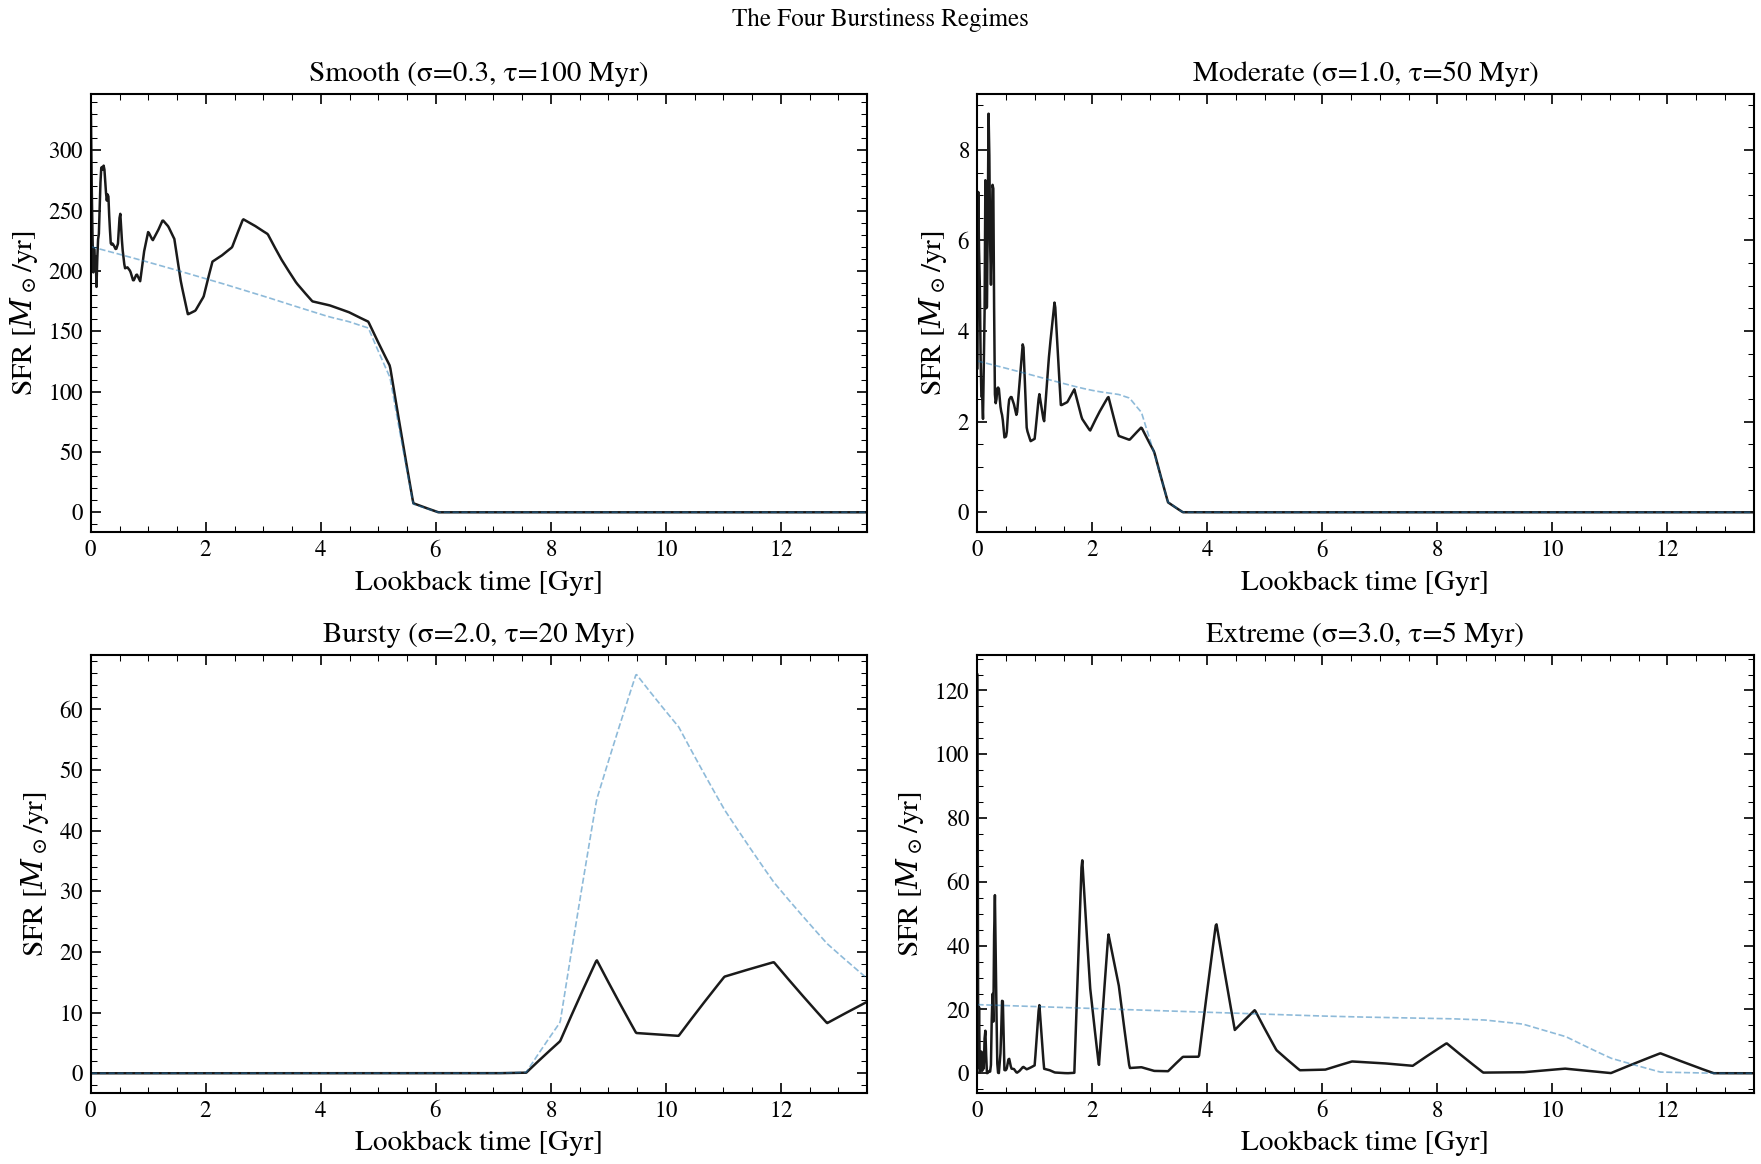

In [4]:
# --- FIGURE 1: 2×2 SFH showcase ---
fig, axes = plt.subplots(2, 2, figsize=(12, 8))
regime_data = {}

for ax, reg in zip(axes.flat, REGIMES):
    key = jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31)
    true_p = spec_stoch.sample(key)
    true_p = {**true_p}
    true_p["sfh_field_psd_sigma"] = jnp.array(reg["sigma"])
    true_p["sfh_field_psd_tau_myr"] = jnp.array(float(reg["tau"]))

    sfh = model_stoch.predict_sfh(true_p)
    t_gyr = np.array(sfh["t_gyr"])
    sfr_full = np.array(sfh["sfr_full"])
    sfr_mean = np.array(sfh["sfr_mean"])

    ax.plot(t_gyr, sfr_full, color=COLORS["truth"], lw=1.2)
    ax.plot(t_gyr, sfr_mean, color=COLORS["sfh_mean"], lw=0.8, ls="--", alpha=0.5)
    ax.set_xlim(0, 13.5)
    ax.set_xlabel("Lookback time [Gyr]")
    ax.set_ylabel(r"SFR [$M_\odot$/yr]")
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']} Myr)")

    regime_data[reg["label"]] = {"params": true_p, "sfh": sfh}

fig.suptitle("The Four Burstiness Regimes", fontsize=12)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig01_burstiness_regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

## Recovery from Spectroscopy

In [5]:
# Fit each regime
regime_results = {}
for reg in REGIMES:
    true_p = regime_data[reg["label"]]["params"]
    mock = model_stoch.mock_spectrum(
        true_p, WAVE_OBS, snr=30.0,
        key=jax.random.PRNGKey(abs(hash(reg["label"])) % 2**31 + 1),
    )
    fitter = Fitter(model_stoch, mock.flux_obs, mock.noise, data_type="spectroscopy")
    _ = fitter.run("map", n_steps=1000, verbose=False)
    res = fitter.run(
        "native_geovi", n_iterations=15, n_samples=6, n_seeds=3,
        n_posterior_samples=2000, verbose=False,
    )
    regime_results[reg["label"]] = res
    print(f"  {reg['label']}: {res.wall_time_s:.1f}s")

assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/.venv/lib/python3.12/site-packages/nifty8/re/model.py:164: UserWarning: drawing white parameters;
to silence this warning, overload the `init` method
  warn(msg)


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:1935: UserWarning: Seeds disagree: H = 134.2 ± 25.7 (CV=19%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  Smooth: 118.5s


...

  Bursty: 113.5s


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


/Users/suchethacooray/Projects/diffsed/src/tengri/inference/fitter.py:1935: UserWarning: Seeds disagree: H = 150.9 ± 17.4 (CV=12%). This may indicate multimodality or poor convergence. Consider increasing n_iterations or inspecting the posterior.
  return self._run_native_vi(


  Extreme: 116.8s


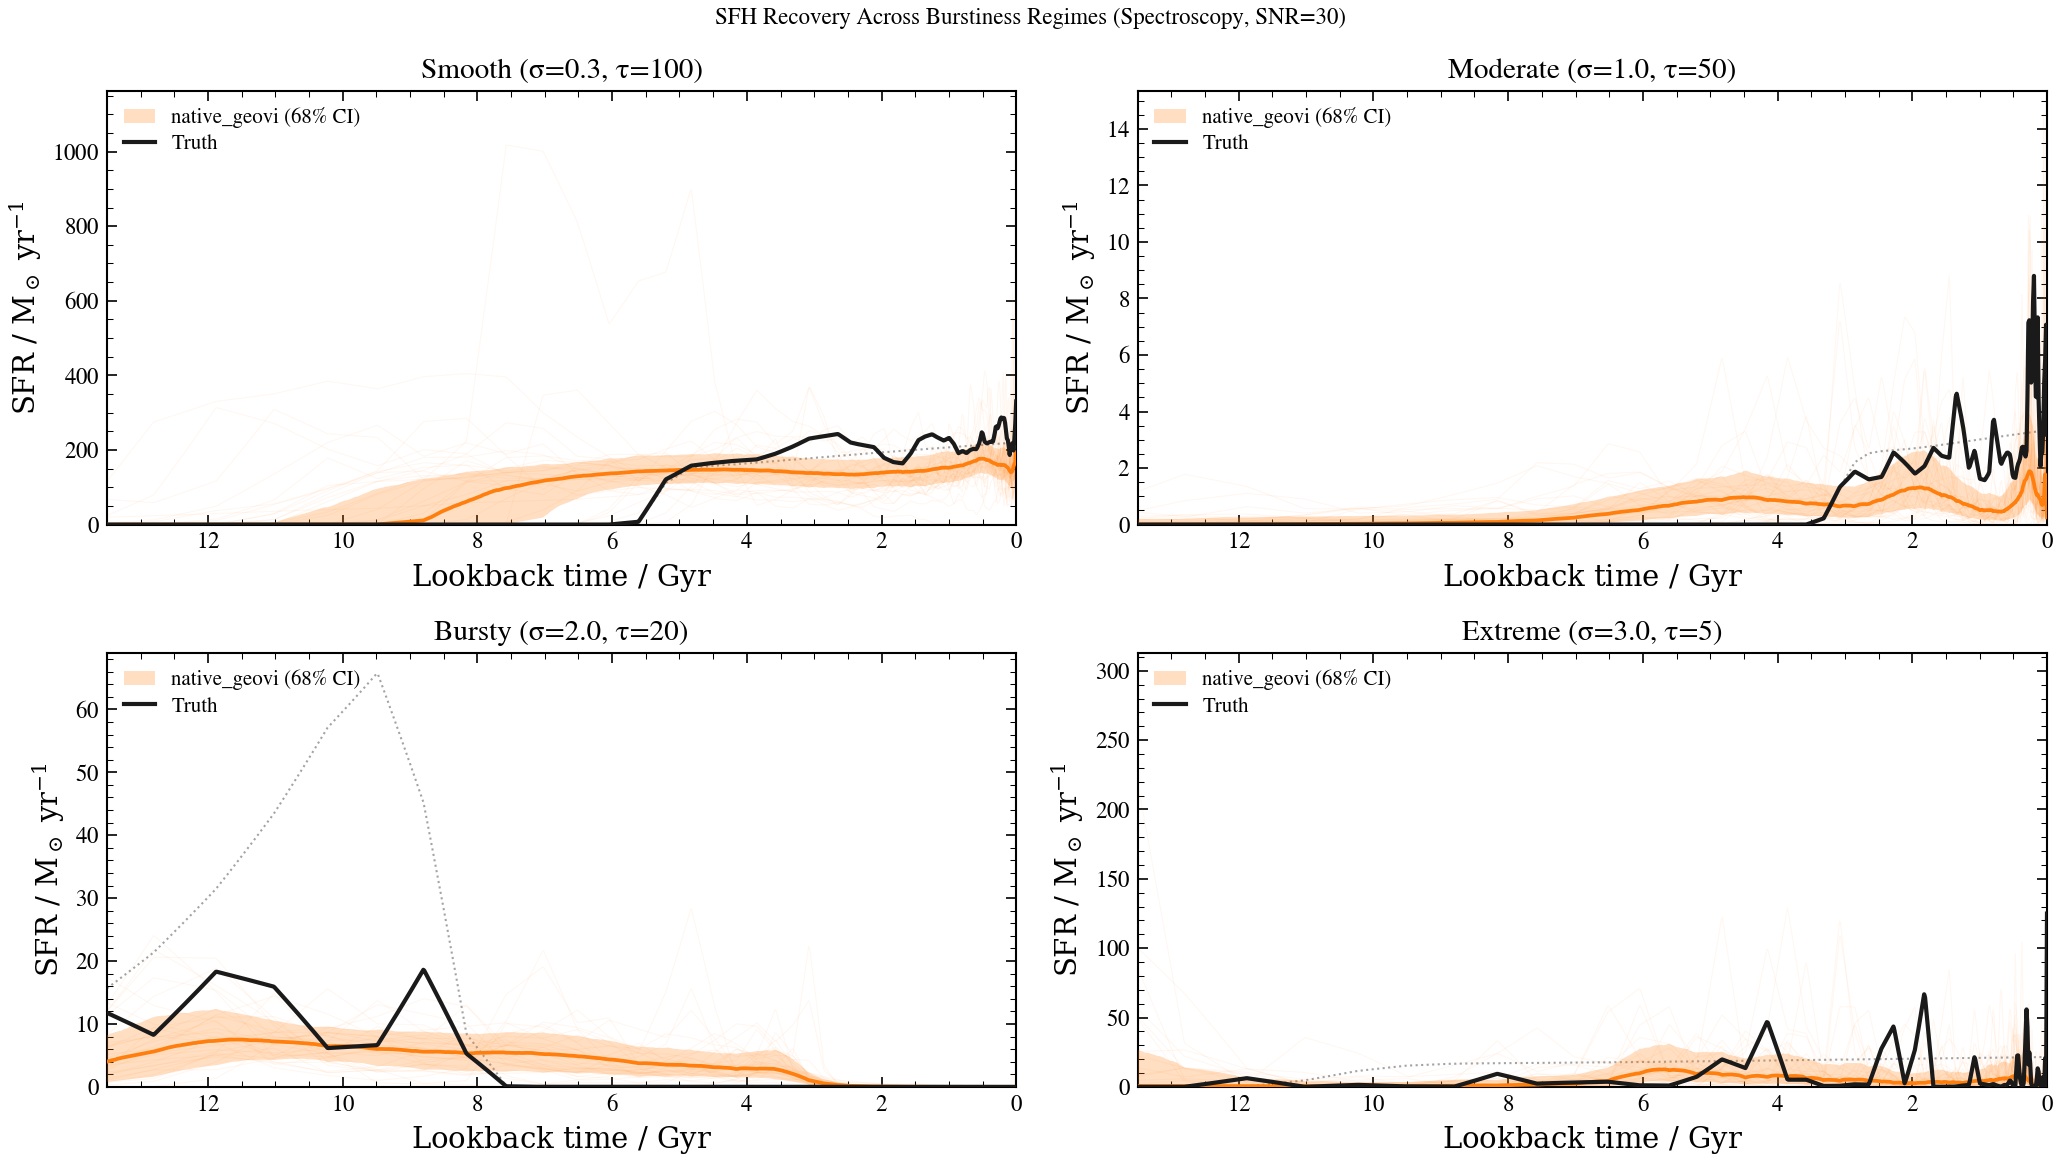

In [6]:
# --- FIGURE 2: 4-panel SFH recovery ---
fig, axes = plt.subplots(2, 2, figsize=(14, 8))
for ax, reg in zip(axes.flat, REGIMES):
    true_p = regime_data[reg["label"]]["params"]
    plot_sfh(model_stoch, regime_results[reg["label"]], true_params=true_p,
             ax=ax, color=COLORS["geovi"], label="native_geovi", method="geoVI",
             show_mean_sfh=True)
    ax.set_title(f"{reg['label']} (σ={reg['sigma']}, τ={reg['tau']})")

fig.suptitle("SFH Recovery Across Burstiness Regimes (Spectroscopy, SNR=30)", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig02_sfh_recovery_4regimes.png"), dpi=150, bbox_inches="tight")
plt.show()

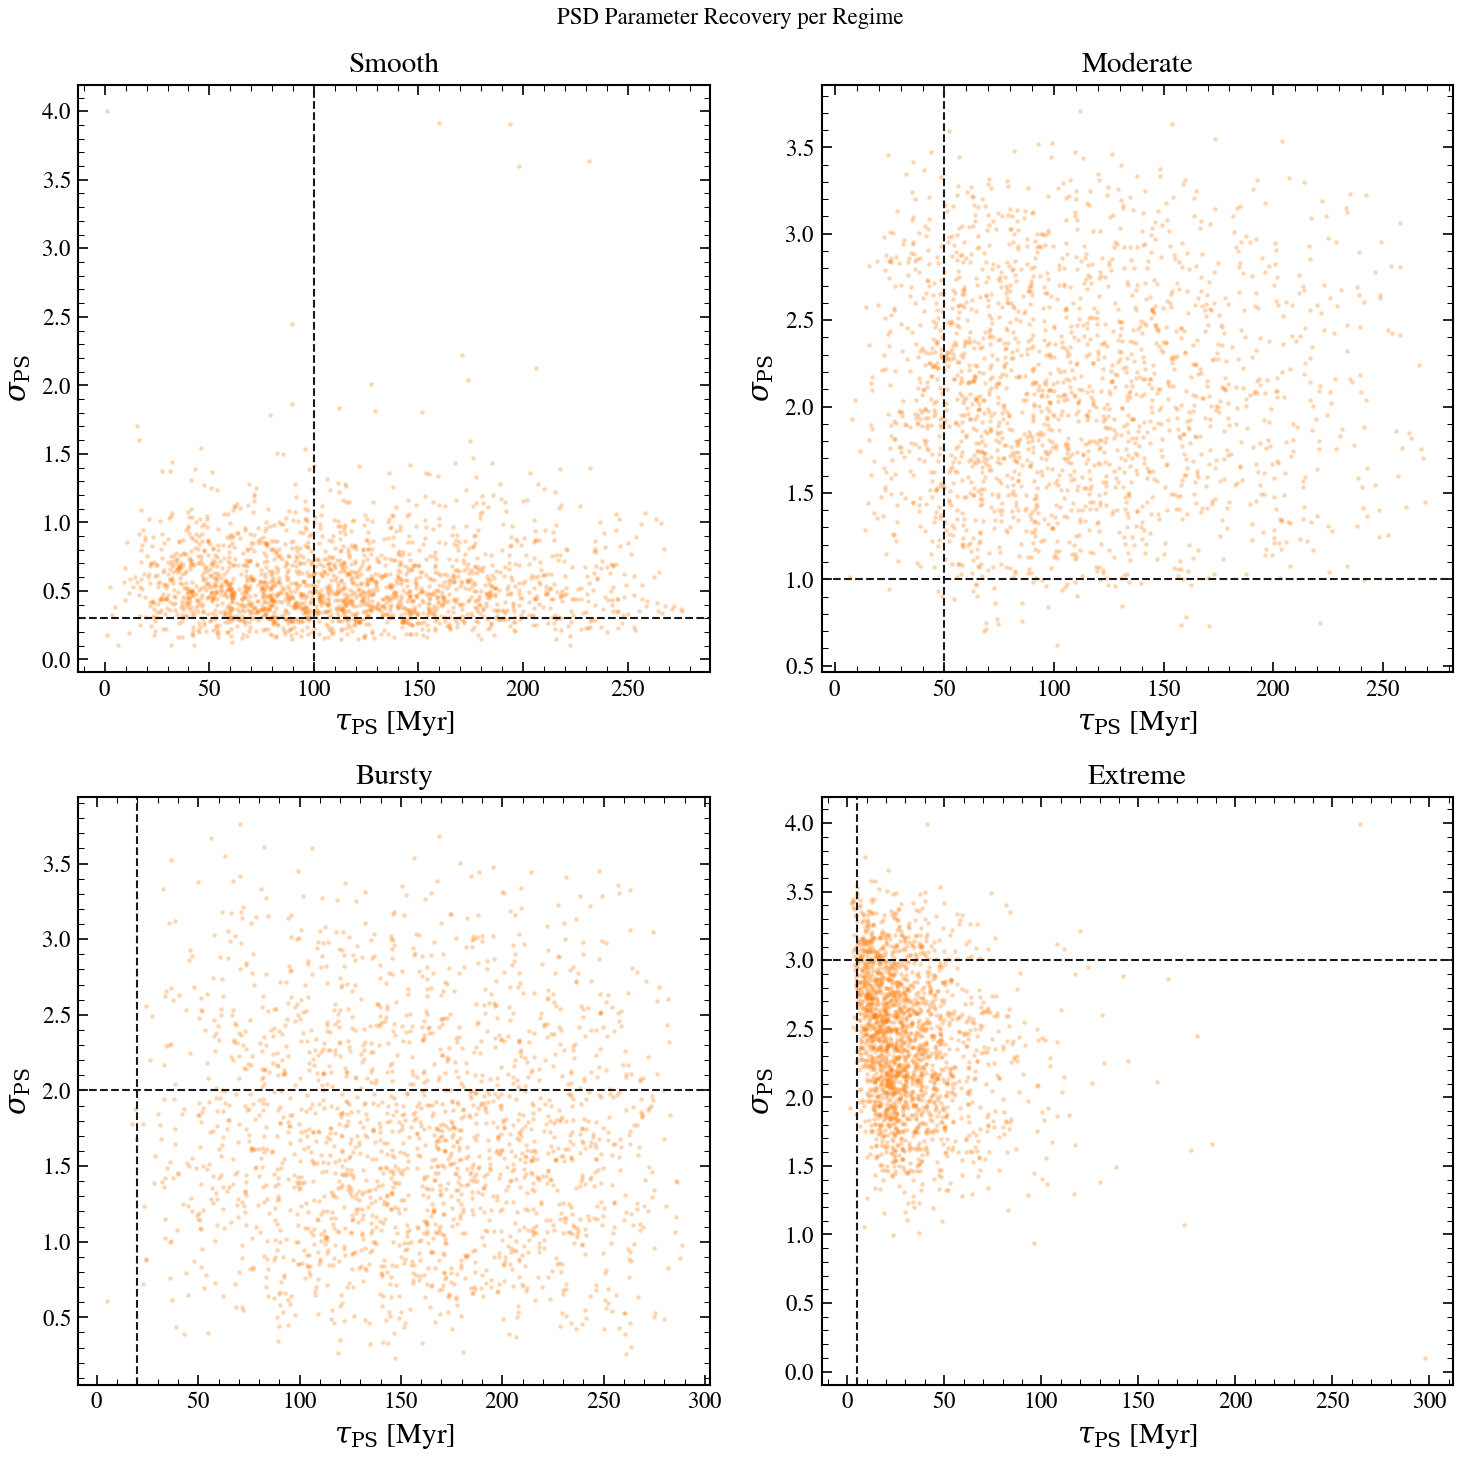

In [7]:
# --- FIGURE 3: PSD corner per regime ---
fig, axes = plt.subplots(2, 2, figsize=(10, 10))
psd_params = ["sfh_field_psd_sigma", "sfh_field_psd_tau_myr"]
for ax, reg in zip(axes.flat, REGIMES):
    res = regime_results[reg["label"]]
    true_p = regime_data[reg["label"]]["params"]
    sig_s = np.array(res.samples["sfh_field_psd_sigma"])
    tau_s = np.array(res.samples["sfh_field_psd_tau_myr"])
    ax.scatter(tau_s, sig_s, s=2, alpha=0.2, color=COLORS["geovi"])
    ax.axhline(float(true_p["sfh_field_psd_sigma"]), color=COLORS["truth"], ls="--", lw=1)
    ax.axvline(float(true_p["sfh_field_psd_tau_myr"]), color=COLORS["truth"], ls="--", lw=1)
    ax.set_xlabel(r"$\tau_{\rm PS}$ [Myr]")
    ax.set_ylabel(r"$\sigma_{\rm PS}$")
    ax.set_title(reg["label"])

fig.suptitle("PSD Parameter Recovery per Regime", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig03_psd_corners.png"), dpi=150, bbox_inches="tight")
plt.show()

## The Wrong Model Trap

A parametric model (no GP) can fit the photometry perfectly — χ² ≈ 1 —
but systematically miss burst features in the SFH. The SED fit looks fine
because broadband photometry averages over timescales shorter than ~100 Myr.

In [8]:
# Fit the "Bursty" regime mock with a PARAMETRIC model
spec_param = ParamSpec(
    sfh_tsnorm_log_peak_sfr=Uniform(-1.0, 2.5),
    sfh_tsnorm_peak_lbt_gyr=Uniform(0.5, 12.0),
    sfh_tsnorm_width_gyr=Uniform(0.3, 5.0),
    sfh_tsnorm_skew=Uniform(-3.0, 3.0),
    sfh_tsnorm_trunc=Uniform(1.0, 10.0),
    met_logzsol=Uniform(-2.0, 0.2),
    dust_tau_bc=Uniform(0.0, 2.0),
    dust_tau_diff=Uniform(0.0, 1.5),
    dust_slope=Fixed(-0.7),
    redshift=Fixed(0.1),
    mean_sfh_type="tsnorm",
)
model_param = Model(spec_param, ssp_data, filters=filters)
model_param.precompute_spectroscopy(WAVE_OBS)

bursty_true = regime_data["Bursty"]["params"]
bursty_mock = model_stoch.mock_spectrum(
    bursty_true, WAVE_OBS, snr=30.0, key=jax.random.PRNGKey(999),
)

# Fit with parametric
fitter_wrong = Fitter(
    model_param, bursty_mock.flux_obs, bursty_mock.noise, data_type="spectroscopy"
)
_ = fitter_wrong.run("map", n_steps=500, verbose=False)
result_wrong = fitter_wrong.run(
    "native_geovi", n_iterations=15, n_samples=6, n_seeds=3,
    n_posterior_samples=2000, verbose=False,
)

/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_8964/3839606307.py:15: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param = Model(spec_param, ssp_data, filters=filters)
/var/folders/km/_d_w3tds0hs4c5pbvflcdt480000gn/T/ipykernel_8964/3839606307.py:16: UserWarning: Fused kernel active with approximations: dust attenuation at filter effective wavelengths (<3% error for most laws, ~36% for SMC); IGM absorption precomputed at filter effective wavelengths. Set approx=False to disable.
  model_param.precompute_spectroscopy(WAVE_OBS)


assuming the specified inverse covariance is diagonal


assuming a diagonal covariance matrix;
setting `std_inv` to `cov_inv(ones_like(data))**0.5`


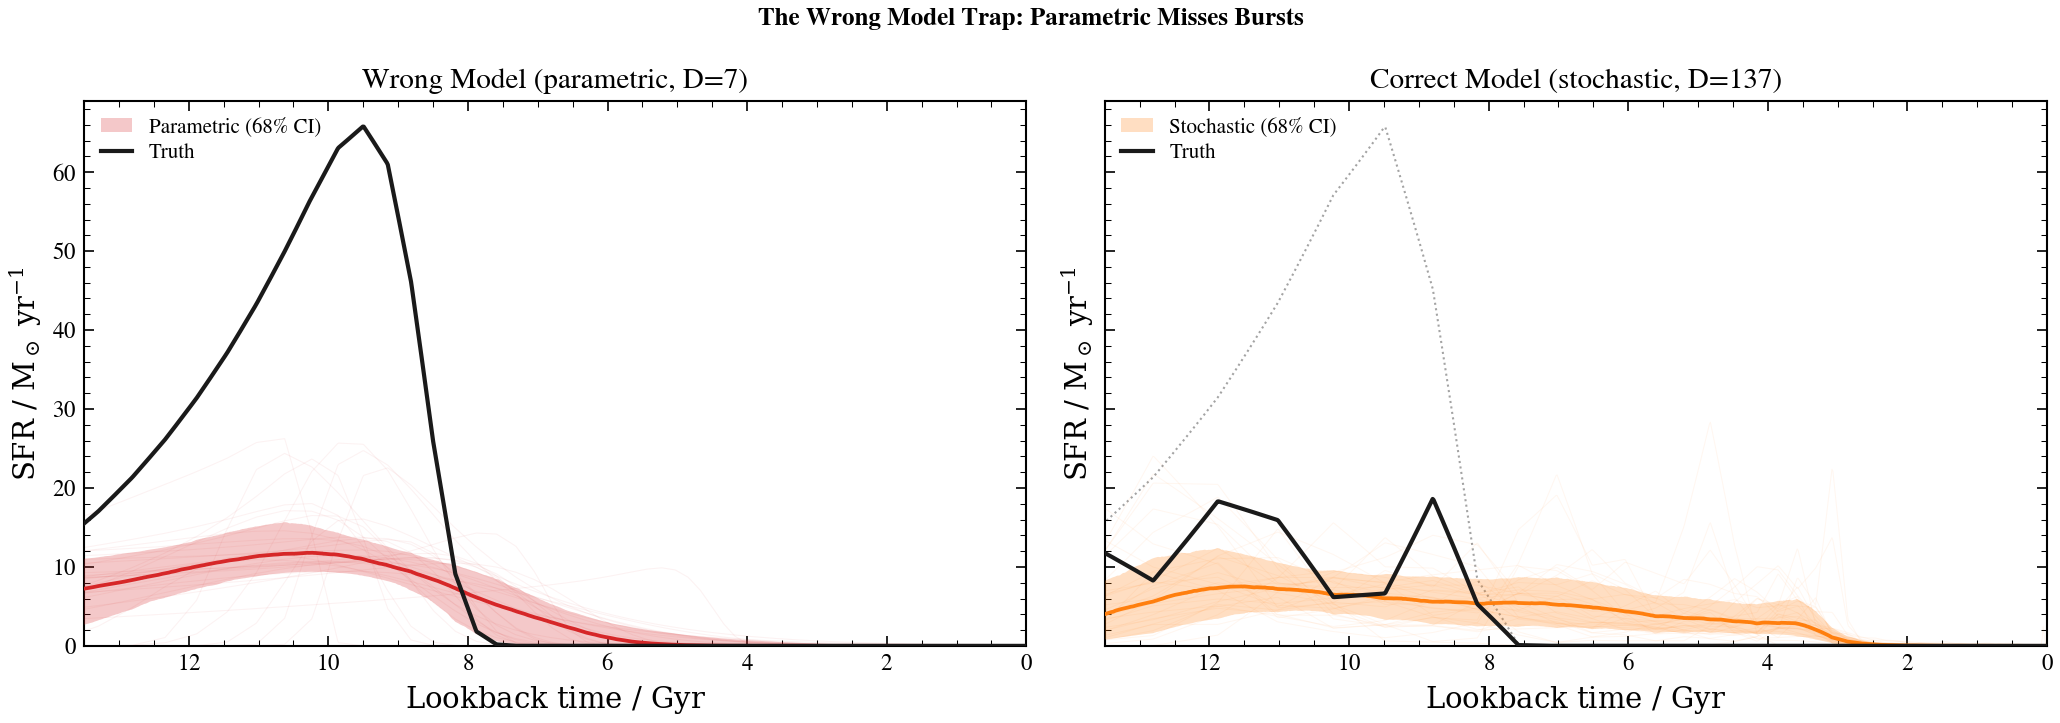

In [9]:
# --- FIGURE 5: Wrong vs correct model (1×2) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 5), sharey=True)

plot_sfh(model_param, result_wrong, true_params=bursty_true,
         ax=ax_wrong, color=COLORS["model"], label="Parametric", method="MAP")
ax_wrong.set_title("Wrong Model (parametric, D=7)")

plot_sfh(model_stoch, regime_results["Bursty"], true_params=bursty_true,
         ax=ax_right, color=COLORS["geovi"], label="Stochastic", method="geoVI",
         show_mean_sfh=True)
ax_right.set_title("Correct Model (stochastic, D=137)")

fig.suptitle("The Wrong Model Trap: Parametric Misses Bursts", fontsize=12, fontweight="bold")
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig05_wrong_model_trap.png"), dpi=150, bbox_inches="tight")
plt.show()

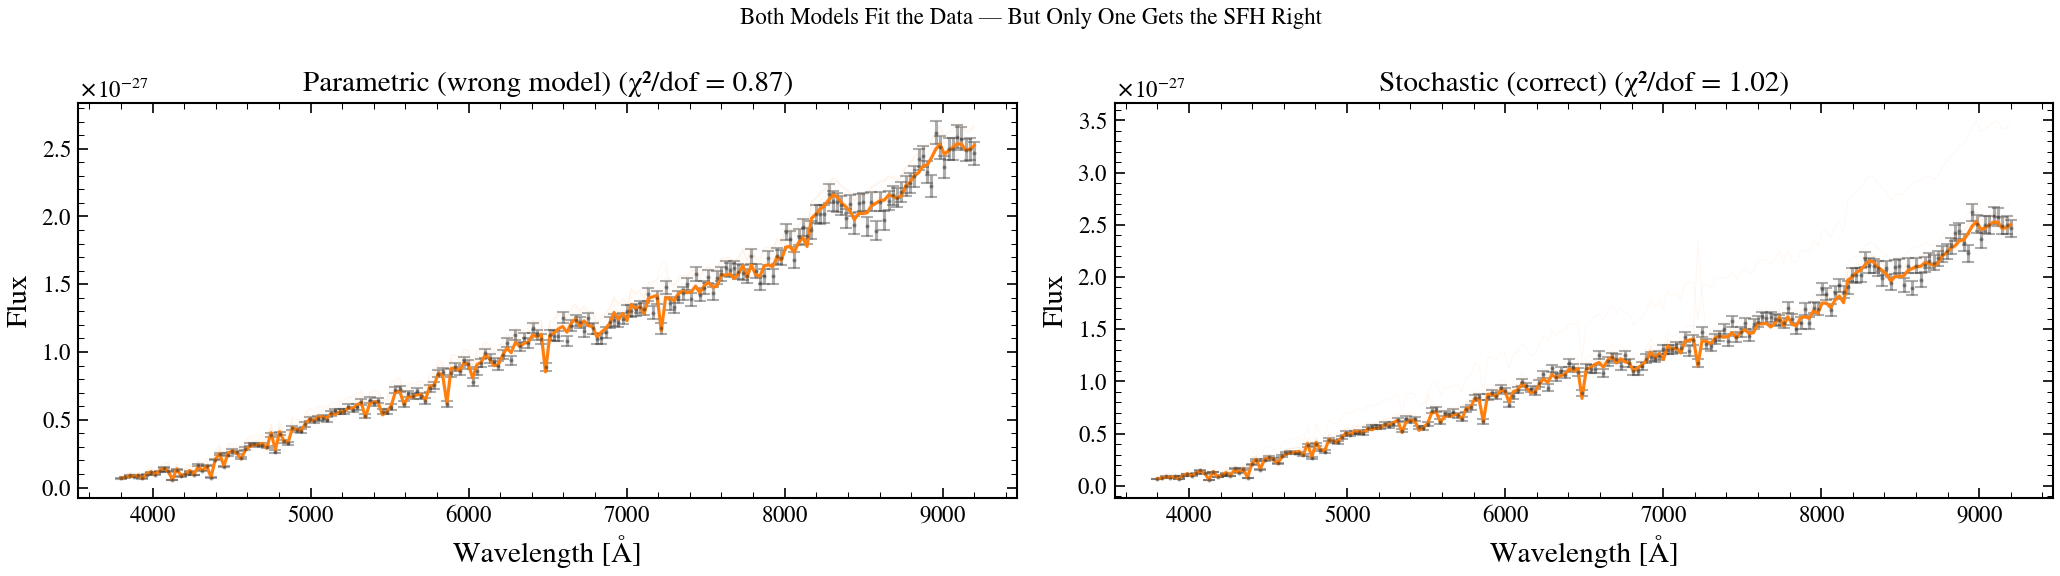

In [10]:
# --- FIGURE 6: Both models fit the data (PPC) ---
fig, (ax_wrong, ax_right) = plt.subplots(1, 2, figsize=(14, 4))

for ax, res, mod, title in [
    (ax_wrong, result_wrong, model_param, "Parametric (wrong model)"),
    (ax_right, regime_results["Bursty"], model_stoch, "Stochastic (correct)"),
]:
    draws = []
    for i in range(30):
        idx = i % len(res.samples[list(res.samples.keys())[0]])
        p = {k: v[idx] for k, v in res.samples.items()}
        draws.append(np.array(mod.predict_spectrum(p)))
    draws = np.array(draws)
    med = np.median(draws, axis=0)

    ax.errorbar(np.array(WAVE_OBS), np.array(bursty_mock.flux_obs),
                yerr=np.array(bursty_mock.noise), fmt=".", ms=2, color=COLORS["data"], alpha=0.4)
    for d in draws:
        ax.plot(np.array(WAVE_OBS), d, color=COLORS["geovi"], alpha=0.05, lw=0.5)
    ax.plot(np.array(WAVE_OBS), med, color=COLORS["geovi"], lw=1.5)

    chi2 = np.sum(((np.array(bursty_mock.flux_obs) - med) / np.array(bursty_mock.noise))**2) / len(med)
    ax.set_title(f"{title} (χ²/dof = {chi2:.2f})")
    ax.set_xlabel("Wavelength [Å]")
    ax.set_ylabel("Flux")

fig.suptitle("Both Models Fit the Data — But Only One Gets the SFH Right", fontsize=11)
fig.tight_layout()
plt.savefig(os.path.join(FIGDIR, "fig06_ppc_both_models.png"), dpi=150, bbox_inches="tight")
plt.show()

## Takeaway

A good spectral fit (χ² ≈ 1) does **not** guarantee correct physical
interpretation. Parametric models smooth over burst features that the
stochastic model captures. Always use the stochastic model when burstiness
matters — especially for recent SFR, sSFR, and emission line predictions.